In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hamsim import hamiltonian, evolution

## Classical vs 1st Order Trotterization

In [2]:
n = 3
H = hamiltonian.ising(n=n)
Hn = hamiltonian.ising_trotter(n=n)

psi0 = np.zeros(2**n, dtype=complex); psi0[1] = 1  # |001>
times = np.linspace(0, 1, 200)

psi_exact = evolution.exact_evolve_series(H, psi0, times)
psi_trotter = evolution.trotter_evolve_series(Hn, psi0, times, n_steps=10)

### Visualize Fidelity and Magnetizaiton

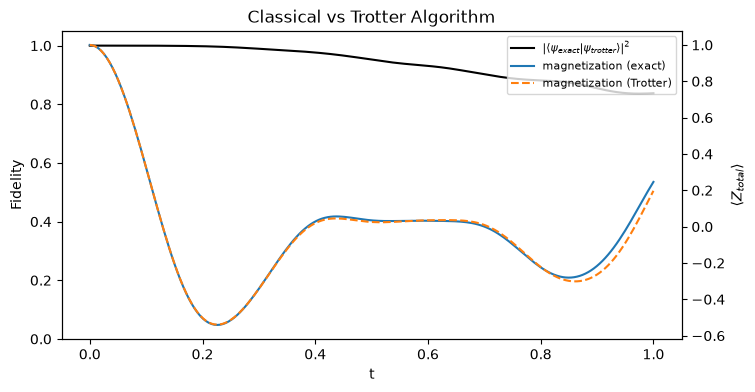

In [3]:

fig, ax = plt.subplots(figsize=(8,4))
fidelity = np.abs(np.sum(psi_exact.conj() * psi_trotter, axis=1))**2
Zn = hamiltonian.ops(hamiltonian.Z(), n)
total_Z = sum(Zn)   # magnetization operator

mag_exact = np.real(np.sum(psi_exact.conj() * (psi_exact @ total_Z.T), axis=1))
mag_trotter = np.real(np.sum(psi_trotter.conj() * (psi_trotter @ total_Z.T), axis=1))


ax.plot(
    times, fidelity, color='black', 
    label=r"$|\langle\psi_{exact}|\psi_{trotter}\rangle|^2$"
)
ax.set_xlabel("t")
ax.set_ylabel("Fidelity")
ax.set_ylim(0, 1.05)

ax1 = ax.twinx()
ax1.plot(times, mag_exact, color='C0', label="magnetization (exact)")
ax1.plot(times, mag_trotter, '--', color='C1', label="magnetization (Trotter)")
ax1.set_ylabel(r"$\langle Z_{total}\rangle$")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

ax.set_title("Classical vs Trotter Algorithm")
plt.show()

### Visualize Trotter infidelity vs step size dt

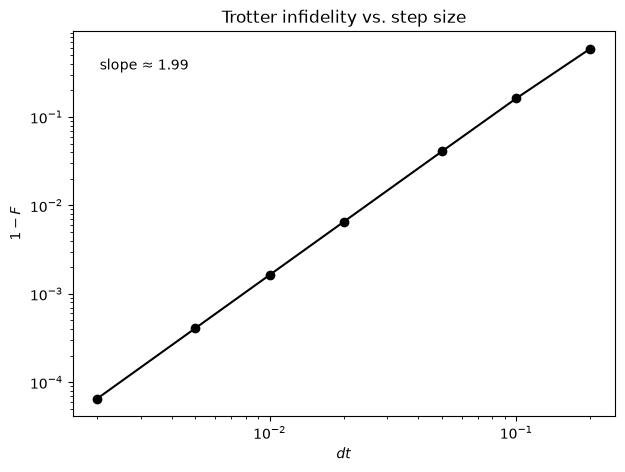

In [4]:
t_final = 1
step_counts = [5, 10, 20, 50, 100, 200, 500]
dts = t_final / np.array(step_counts)
psi_exact_final = evolution.exact_evolve(H, psi0, t_final)

infidelities = []
for n_steps in step_counts:
    psi_trotter_final = evolution.trotter_evolve(Hn, psi0, t_final, n_steps)
    fidelity = np.abs(np.vdot(psi_exact_final, psi_trotter_final))**2
    infidelities.append(1 - fidelity)

fig, ax = plt.subplots(figsize=(7,5))
ax.loglog(dts, infidelities, 'ko-')
ax.set_xlabel(r"$dt$")
ax.set_ylabel(r"$1 - F$")
ax.set_title("Trotter infidelity vs. step size")

# fit a power law: infidelity ~ C * dt^p
slope, intercept = np.polyfit(np.log(dts), np.log(infidelities), 1)
ax.text(0.05, 0.9, f"slope ≈ {slope:.2f}", transform=ax.transAxes)
plt.show()


### Test Trotterization Efficiency

In [5]:
import time

n_values = [4, 6, 8, 10, 12]
dense_times = []
local_times = []

for n in n_values:
    H = hamiltonian.ising(n=n) 
    H_local = hamiltonian.ising_trotter(n=n)
    psi0 = np.zeros(2**n, dtype=complex); psi0[1] = 1

    start = time.perf_counter()
    _ = evolution.exact_evolve(H, psi0, t_final)
    dense_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    _ = evolution.trotter_evolve(H_local, psi0, t_final, n_steps=20)
    local_times.append(time.perf_counter() - start)

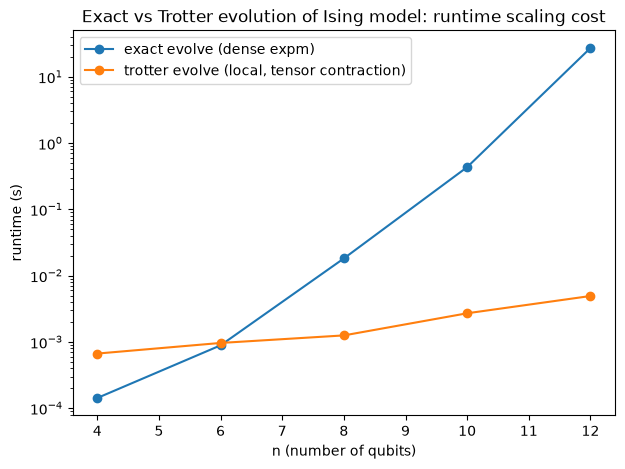

In [6]:
fig, ax = plt.subplots(figsize=(7,5))
ax.semilogy(n_values, dense_times, 'o-', label="exact evolve (dense expm)")
ax.semilogy(n_values, local_times, 'o-', label="trotter evolve (local, tensor contraction)")
ax.set_xlabel("n (number of qubits)")
ax.set_ylabel("runtime (s)")
ax.legend()
ax.set_title("Exact vs Trotter evolution of Ising model: runtime scaling cost")
fig.savefig('../docs/figures/runtime_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
log_times = np.log(dense_times)
slope, intercept = np.polyfit(n_values, log_times, 1)
print(f"dense_evolve time ~ exp({slope:.3f} * n)")
print(f"equivalently, base-2 growth rate: {np.exp(slope):.3f}^n")

dense_evolve time ~ exp(1.526 * n)
equivalently, base-2 growth rate: 4.598^n


At N=12 qubits, exact diagonalization takes 26.8 s per
evolution, versus 4.93 ms for the efficient Trotter
step — roughly a 5436× speedup. The dense approach's runtime
grows approximately as [exp(slope):.2f}^n ([slope:.2f} in log-time per
qubit added), consistent with the expected cubic scaling in Hilbert
space dimension ($O(8^n)$) for dense matrix exponentiation, while the
local implementation's cost per step remains close to constant,
reflecting its independence from total system size.